## Real Stock Portfolio Optimization (Binary VQE Client)

This notebook is a **real-market-data example client** for the package's binary VQE workflow.

### Pipeline

1. Download adjusted prices for a small equity universe.
2. Estimate annualized expected returns $\mu$ and covariance $\Sigma$.
3. Solve a cardinality-constrained selection problem with Binary VQE:

$$
\min_{x \in \{0,1\}^n} \; \lambda x^\top \Sigma x - \mu^\top x + \alpha(\mathbf{1}^\top x - K)^2.
$$

The notebook reports both the marginal inclusion probabilities and the final Top-K projection used for a concrete portfolio choice.

### Requirements

Install the optional market-data dependencies first:

```bash
pip install \"vqe-portfolio[data]\"
```

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from vqe_portfolio import get_stock_data, run_binary_vqe
from vqe_portfolio.plotting import bar_allocations, plot_trace
from vqe_portfolio.types import BinaryVQEConfig
from vqe_portfolio.utils import resolve_notebook_outdir, set_global_seed

SEED = 0
set_global_seed(SEED)

OUTDIR = resolve_notebook_outdir()

## Data configuration

In [2]:
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]
start = "2024-01-01"
end = "2025-01-01"

use_log = True
shrink = "lw"
scale = "none"

mu_s, Sigma_df, prices = get_stock_data(
    tickers,
    start=start,
    end=end,
    auto_adjust=True,
    use_log=use_log,
    shrink=shrink,
    scale=scale,
)

mu = np.array(mu_s.loc[tickers].values, dtype=float)
Sigma = np.array(Sigma_df.loc[tickers, tickers].values, dtype=float)

print("Tickers:", tickers)
print("Annualized mu:")
for t, m in zip(tickers, mu):
    print(f"  {t}: {float(m): .6f}")
print("\nSigma (annualized) shape:", Sigma.shape)
print("Prices rows:", prices.shape[0])

Tickers: ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN']
Annualized mu:
  AAPL:  0.294857
  MSFT:  0.131251
  NVDA:  0.994034
  GOOGL:  0.308668
  AMZN:  0.368969

Sigma (annualized) shape: (5, 5)
Prices rows: 261


## Run Binary VQE

In [3]:
K = 2
LAM = 3.0
ALPHA = 8.0

cfg = BinaryVQEConfig(
    depth=2,
    steps=80,
    stepsize=0.20,
    log_every=10,
    shots_train=None,
    shots_sample=1000,
    lam=LAM,
    alpha=ALPHA,
    k=K,
    seed=SEED,
    device="default.qubit",
)

res = run_binary_vqe(mu, Sigma, cfg)

x_prob = np.array(res.x_prob, dtype=float)
x_topk = np.array(res.x_topk, dtype=int)

selected_idx = np.where(x_topk == 1)[0]
selected_tickers = [tickers[i] for i in selected_idx]
equal_weight_portfolio = x_topk / max(int(x_topk.sum()), 1)

port_ret = float(mu @ equal_weight_portfolio)
port_var = float(equal_weight_portfolio @ Sigma @ equal_weight_portfolio)
port_risk = float(np.sqrt(max(port_var, 0.0)))

print("Marginal inclusion probabilities:")
for t, p in zip(tickers, x_prob):
    print(f"  {t}: {float(p):.4f}")

print("\nTop-K selection:", selected_tickers)
print(f"Equal-weight selected portfolio return: {port_ret:.6f}")
print(f"Equal-weight selected portfolio risk  : {port_risk:.6f}")

print("\nMost frequent sampled bitstrings:")
top_counts = sorted(res.sample_counts.items(), key=lambda kv: kv[1], reverse=True)[:5]
for bitstring, count in top_counts:
    print(f"  {bitstring}: {count}")

Marginal inclusion probabilities:
  AAPL: 0.0002
  MSFT: 0.0025
  NVDA: 0.9957
  GOOGL: 0.0025
  AMZN: 0.9994

Top-K selection: ['NVDA', 'AMZN']
Equal-weight selected portfolio return: 0.681501
Equal-weight selected portfolio risk  : 0.335301

Most frequent sampled bitstrings:
  00101: 994
  00011: 3
  00110: 1
  01001: 1
  11101: 1


## Convergence plot

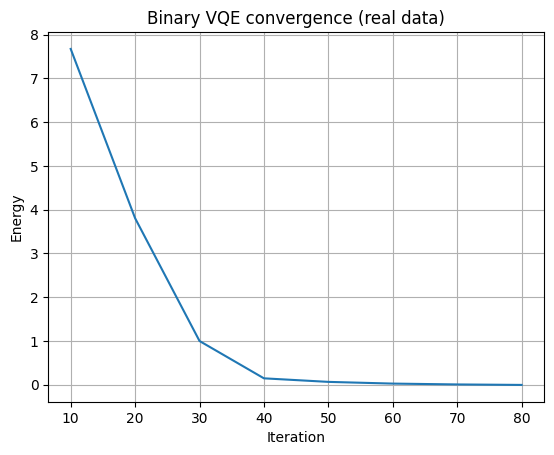

In [4]:
plot_trace(
    res.energy_trace.steps,
    res.energy_trace.values,
    xlabel="Iteration",
    ylabel="Energy",
    title="Binary VQE convergence (real data)",
    outpath=OUTDIR / "Binary_VQE_Convergence_Real_Example_02.png",
)
plt.show()

## Selection plots

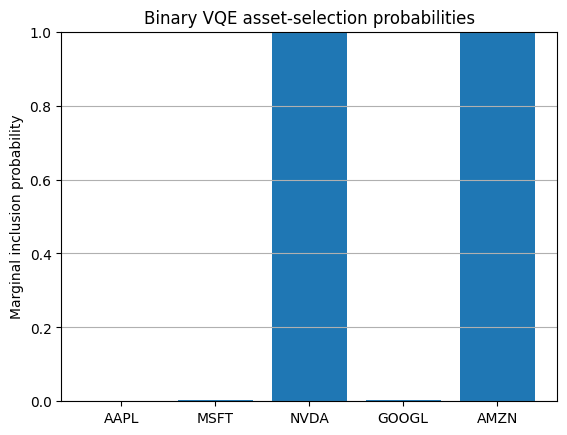

In [5]:
bar_allocations(
    tickers,
    x_prob,
    ylabel="Marginal inclusion probability",
    title="Binary VQE asset-selection probabilities",
    ylim=(0.0, 1.0),
    outpath=OUTDIR / "Binary_VQE_Probabilities_Real_Example_02.png",
)
plt.show()

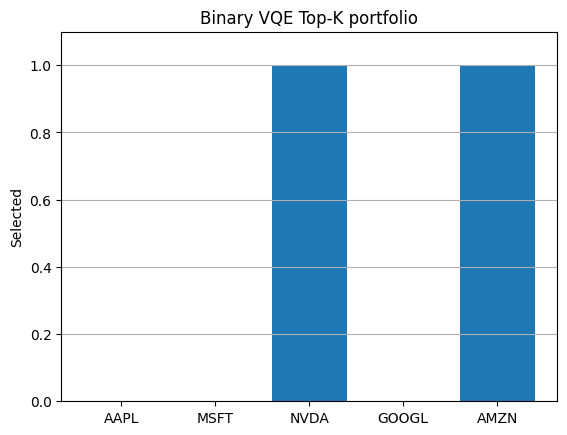

In [6]:
bar_allocations(
    tickers,
    x_topk,
    ylabel="Selected",
    title="Binary VQE Top-K portfolio",
    ylim=(0.0, 1.1),
    outpath=OUTDIR / "Binary_VQE_TopK_Real_Example_02.png",
)
plt.show()